In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv("../outputs/feature_sets.csv")

summary = (
    df.groupby("k")
    .agg(
        mean_r2 = ("r2", "mean"),
        sd_r2 = ("r2", "std"),
        mean_mse=("mse", "mean"),
        sd_mse=("mse", "std"),
    )
    .reset_index()
)

In [3]:
summary

,k,mean_r2,sd_r2,mean_mse,sd_mse
0,1,0.011700,0.043163,0.375345,0.016393
1,2,0.020359,0.059554,0.372057,0.022618
2,3,0.024240,0.062531,0.370583,0.023748
3,5,0.032772,0.067697,0.367343,0.025711
4,9,0.069661,0.087619,0.353333,0.033277
5,13,0.096846,0.097402,0.343008,0.036992
6,21,0.141547,0.113531,0.326031,0.043118
7,33,0.188541,0.105383,0.308183,0.040023
8,52,0.240869,0.104032,0.288309,0.039510
9,81,0.264428,0.093733,0.279362,0.035599


<Axes: xlabel='k'>

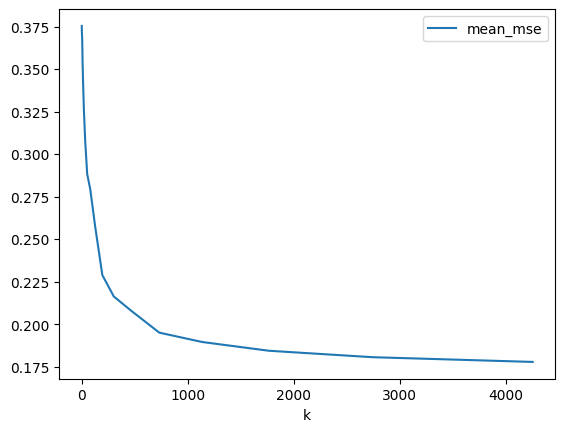

In [4]:
summary.plot(x='k', y='mean_mse')

<Axes: xlabel='k'>

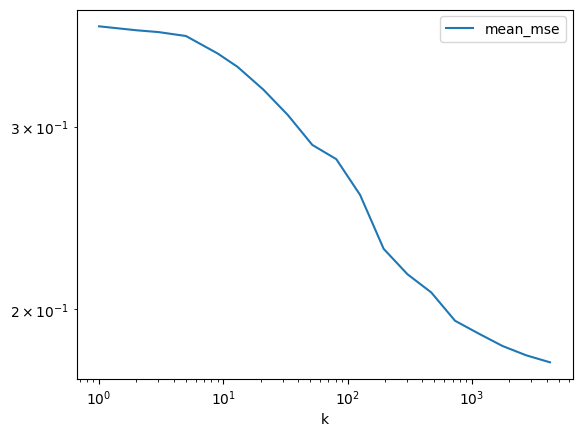

In [5]:
summary.plot(x='k', y='mean_mse', loglog=True)

In [6]:
def power_law(n, C, alpha, epsilon):
    return C* n **(-alpha) + epsilon

In [7]:
from scipy.optimize import curve_fit

k = summary["k"].values
mse = summary["mean_mse"].values

p0 = [
    max(mse) - min(mse),
    0.5,
    min(mse)
]

params, _ = curve_fit(power_law, k, mse, p0=p0, maxfev=10000)

C_hat, alpha_hat, epsilon_hat = params

In [8]:
print("C:", C_hat)
print("alpha:", alpha_hat)
print("epsilon (asymptote):", epsilon_hat)

C: 317.0364293952542
alpha: 9.153941307061533e-05
epsilon (asymptote): -316.63577801743276


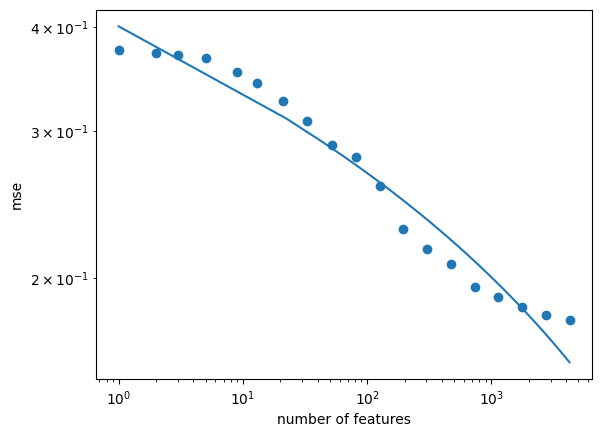

In [9]:
import numpy as np
n_smooth = np.linspace(min(k), max(k), 200)

plt.scatter(k, mse, label="data")
plt.plot(n_smooth, power_law(n_smooth, *params), label="fit")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("number of features")
plt.ylabel("mse")
plt.show()

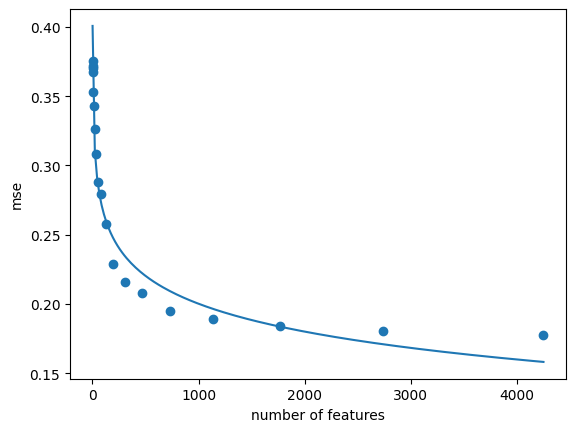

In [10]:
plt.scatter(k, mse, label="data")
plt.plot(n_smooth, power_law(n_smooth, *params), label="fit")
plt.xlabel("number of features")
plt.ylabel("mse")
plt.show()

In [11]:
# fit something else ?
def shifted_power_law(n, C, alpha, epsilon, d):
    return C * (n + d) ** (-alpha) + epsilon

In [12]:
def exp_decay(n, A, k, epsilon):
    return A * np.exp(-k * n) + epsilon

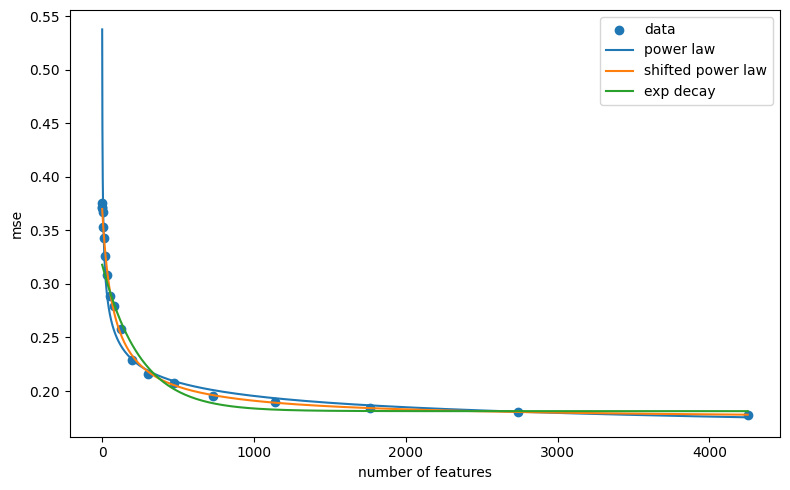

power law params: [0.40332764 0.27313946 0.13430851]
shifted power law params: [ 6.41937414  0.83642438  0.17207723 63.05477476]
exp decay params: [0.13722649 0.00400226 0.18123754]


In [13]:

# -----------------------------
# fit models
# -----------------------------

# optional weighting so large-n points matter more
weights = 1 / np.sqrt(k)

# initial guesses help optimization a lot
p0_power = [1.0, 0.5, 0.18]
p0_shift = [1.0, 0.5, 0.18, 10.0]
p0_exp = [0.25, 0.001, 0.18]

params_power, _ = curve_fit(
    power_law,
    k,
    mse,
    p0=p0_power,
    sigma=weights,
    absolute_sigma=False,
    maxfev=10000
)

params_shift, _ = curve_fit(
    shifted_power_law,
    k,
    mse,
    p0=p0_shift,
    sigma=weights,
    absolute_sigma=False,
    maxfev=10000
)

params_exp, _ = curve_fit(
    exp_decay,
    k,
    mse,
    p0=p0_exp,
    sigma=weights,
    absolute_sigma=False,
    maxfev=10000
)

# -----------------------------
# smooth curves
# -----------------------------

n_smooth = np.logspace(np.log10(min(k)), np.log10(max(k)), 400)

# predictions
y_power = power_law(n_smooth, *params_power)
y_shift = shifted_power_law(n_smooth, *params_shift)
y_exp = exp_decay(n_smooth, *params_exp)

# -----------------------------
# plot
# -----------------------------

plt.figure(figsize=(8, 5))

plt.scatter(k, mse, label="data")

plt.plot(n_smooth, y_power, label="power law")
plt.plot(n_smooth, y_shift, label="shifted power law")
plt.plot(n_smooth, y_exp, label="exp decay")

#plt.xscale("log")
# try commenting this out too
# plt.yscale("log")

plt.xlabel("number of features")
plt.ylabel("mse")

plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# print parameters
# -----------------------------

print("power law params:", params_power)
print("shifted power law params:", params_shift)
print("exp decay params:", params_exp)

In [14]:
std = summary["sd_mse"]

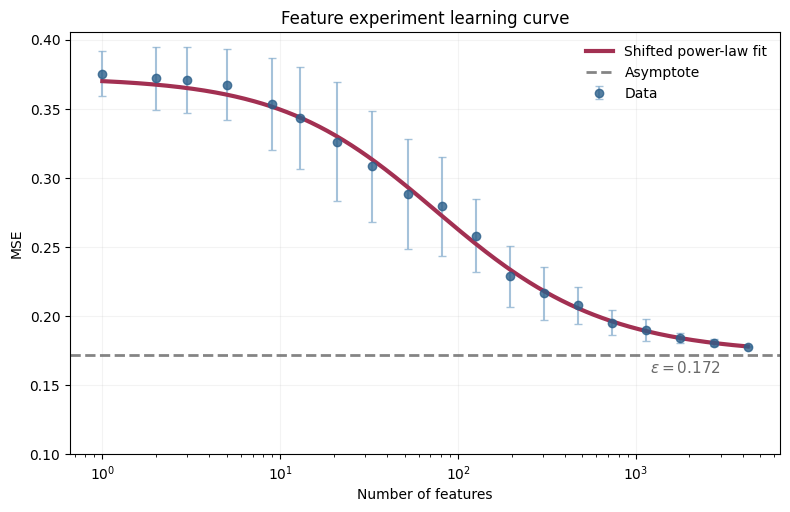

In [16]:
# shifted power law seems the best 
import numpy as np
import matplotlib.pyplot as plt

# choose the model you want to present
# for example: shifted power law
y_fit = shifted_power_law(n_smooth, *params_shift)

# asymptote for shifted power law
# adjust index if your parameter order differs
epsilon_hat = params_shift[2]

fig, ax = plt.subplots(figsize=(8, 5))

data_colour = "#2C5F8A"
error_colour = "#8FB3D1"

ax.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.8,
    label="Data",
    color = data_colour,
    ecolor= error_colour
)

ax.plot(
    n_smooth,
    y_fit,
    color="#A23052",
    lw=3,
    label="Shifted power-law fit"
)

ax.axhline(
    epsilon_hat,
    color="#666666",
    ls="--",
    lw=2,
    alpha=0.8,
    label = "Asymptote"
)

plt.text(
    1200,
    epsilon_hat - 0.013,
    fr'$\epsilon={epsilon_hat:.3f}$',
    fontsize=11,
    color='dimgray'
)

ax.set_xscale("log")
ax.set_xlabel("Number of features")
ax.set_ylabel("MSE")
ax.set_ylim(0.1)
ax.legend(frameon=False)
ax.grid(alpha=0.15)
fig.tight_layout()
plt.title('Feature experiment learning curve')
plt.savefig('../outputs/figures/feature_set.pdf', format='pdf', bbox_inches='tight')
plt.show()